In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

print("All good!")

Matplotlib is building the font cache; this may take a moment.


All good!


In [7]:
df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')
print(df.shape)   # How many rows and columns?
print(df.head())  # First 5 rows
print(df.isnull().sum())  # Any missing values?

(4572, 4)
     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


In [8]:
# Remove rows with missing values
df = df.dropna()

# Confirm they're gone
print(df.isnull().sum())
print(df.shape)

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64
(4546, 4)


                    TV     Radio  Social_Media     Sales
TV            1.000000  0.869158      0.527687  0.999497
Radio         0.869158  1.000000      0.606338  0.868638
Social_Media  0.527687  0.606338      1.000000  0.527446
Sales         0.999497  0.868638      0.527446  1.000000


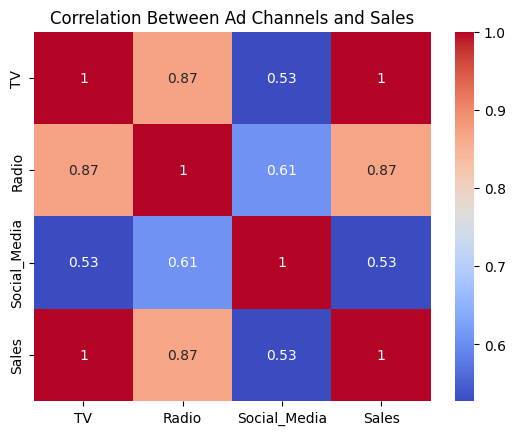

In [9]:
# Check correlation of everything with Sales
print(df.corr())

# Visual heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Ad Channels and Sales')
plt.show()

In [10]:
# X = TV (our predictor), y = Sales (what we're predicting)
X = df['TV']
y = df['Sales']

# Add intercept
X = sm.add_constant(X)

# Build and fit the model
model = sm.OLS(y, X).fit()

# Show results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        00:59:24   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

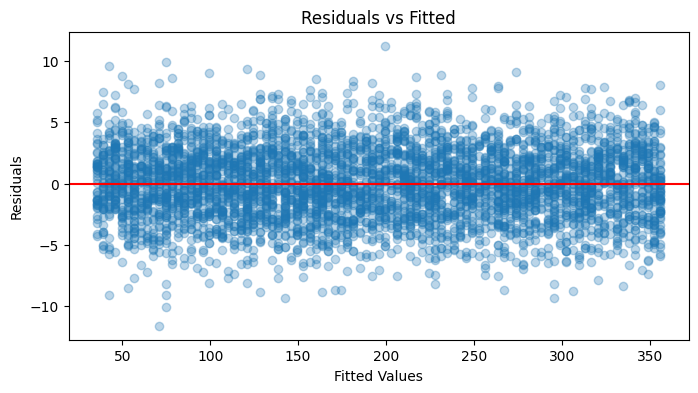

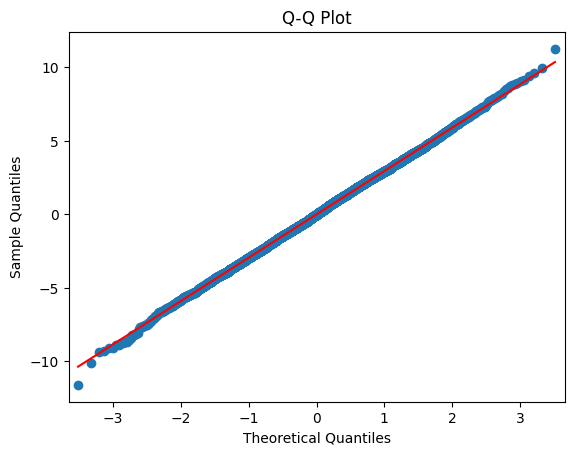

In [11]:
fitted = model.fittedvalues
residuals = model.resid

# Plot 1: Residuals vs Fitted
plt.figure(figsize=(8,4))
plt.scatter(fitted, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.title('Residuals vs Fitted')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# Plot 2: Q-Q Plot (Normality check)
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot')
plt.show()

## Business Recommendation

TV advertising has the strongest correlation with Sales (r = 0.9995).

The regression model shows:
- For every 1 unit increase in TV spend, Sales increases by 3.56 units
- The model explains 99.9% of all sales variation (R² = 0.999)
- This result is statistically significant (p < 0.05)

**Recommendation:** Allocate the majority of the marketing budget 
to TV advertising for maximum ROI.